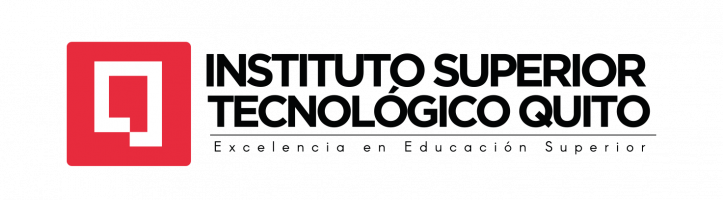

# Examen primer Parcial

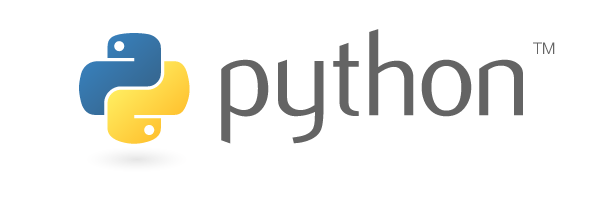

*Mathew Santiago Lara Villalva*

*Link del Git Hub:[Mathew Lara](https://github.com/MathewLara/CuadernoPythonML2.git)*

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn import preprocessing, linear_model, metrics
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_error
from kaggle.api.kaggle_api_extended import KaggleApi

# Carga y comprensión de los datos

In [26]:
print("--- 1. Carga de Datos desde Kaggle ---")
# Configuración de credenciales de Kaggle
os.environ['KAGGLE_USERNAME'] = "mathewlara"
os.environ['KAGGLE_KEY'] = "KGAT_01d1881d9946fc4392406efb82535ff2"

# Descarga automatizada
try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    # Descargamos el dataset (mirichoi0218/insurance)
    api.dataset_download_files('mirichoi0218/insurance', path='.', unzip=True)
    print("Descarga exitosa.")
except Exception as e:
    print("Asegúrate de tener instalada la librería kaggle (`pip install kaggle`). Error:", e)

#Carga De Datos    
df = pd.read_csv('insurance.csv')
print("\nDimensiones originales del dataset:", df.shape)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

--- 1. Carga de Datos desde Kaggle ---
Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
Descarga exitosa.

Dimensiones originales del dataset: (1338, 7)

Primeras 5 filas del dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA y calidad de los datos


--- 2. Análisis Exploratorio (EDA) y Calidad ---

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Estadísticas descriptivas de variables numéricas:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


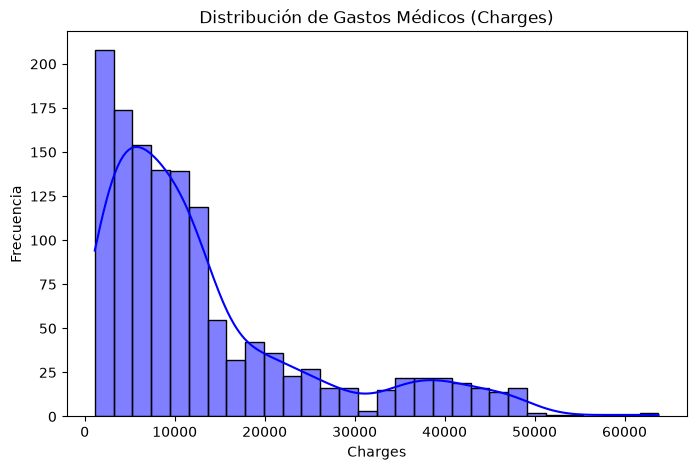

In [27]:
print("\n--- 2. Análisis Exploratorio (EDA) y Calidad ---")
print("\nInformación general del dataset:")
df.info()

print("\nEstadísticas descriptivas de variables numéricas:")

display(df.describe())
# Verificamos si hay valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Distribución de la variable objetivo 'charges'
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, bins=30, color='blue')
plt.title('Distribución de Gastos Médicos (Charges)')
plt.xlabel('Charges')
plt.ylabel('Frecuencia')
plt.show()

# Detección de outliers


--- 3. Detección de Outliers (Cajas y Bigotes) ---


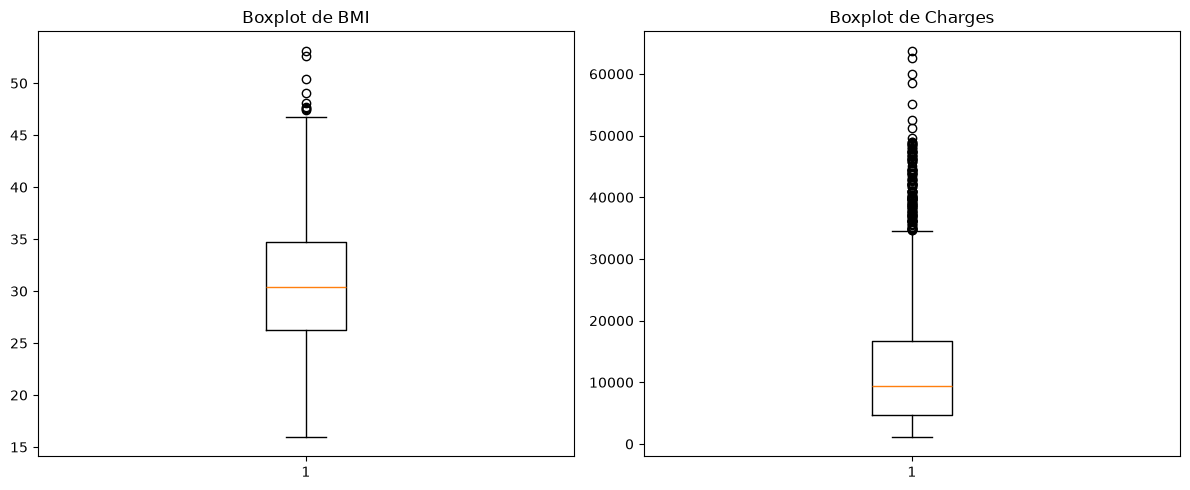

limite inferior bmi:  13.7
limite superior bmi:  47.290000000000006
Número de outliers en bmi:  9
Outliers de 'bmi' eliminados del dataset.


In [28]:
print("\n--- 3. Detección de Outliers (Cajas y Bigotes) ---")
import scipy.stats as stats
import numpy as np

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['bmi'])
plt.title('Boxplot de BMI')

plt.subplot(1, 2, 2)
plt.boxplot(df['charges'])
plt.title('Boxplot de Charges')
plt.tight_layout()
plt.show()

# Seleccionamos el atributo que vamos a medir
a = df['bmi']

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)
RIC = Q3 - Q1
li = Q1 - 1.5 * RIC # xmin
ls = Q3 + 1.5 * RIC # xmax

print('limite inferior bmi: ', li)
print('limite superior bmi: ', ls)

# Buscamos la posición de los outliers
pos_i = np.where(a < li)[0]
pos_s = np.where(a > ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s))

print('Número de outliers en bmi: ', len(pos_outliers))

# Eliminamos los outliers
df = df.drop(pos_outliers).reset_index(drop=True)
print("Outliers de 'bmi' eliminados del dataset.")

# Preparación de variables

In [29]:
print("\n--- 4. Preparación de Variables ---")
# Las variables 'sex', 'smoker' y 'region' son categóricas (nominales).
# Debemos convertirlas a numéricas para la regresión usando One-Hot Encoding (pd.get_dummies)

df_preparado = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
# drop_first=True evita la multicolinealidad (trampa de variables dummy)

print("Variables después de la transformación dummy:")
print(df_preparado.columns)

# Separar atributos (X) y clase objetivo (y)
X = df_preparado.drop('charges', axis=1)
y = df_preparado['charges']


--- 4. Preparación de Variables ---
Variables después de la transformación dummy:
Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


# Validación de datos (Partición externa)

In [30]:
print("\n--- 5. Validación de Datos ---")
# Separamos el 80% para entrenamiento y 20% para test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Dimensiones de X_train: ', np.shape(X_train))
print('Dimensiones de X_test: ', np.shape(X_test))


--- 5. Validación de Datos ---
Dimensiones de X_train:  (1063, 8)
Dimensiones de X_test:  (266, 8)


# Normalización/Estandarización

In [31]:
print("\n--- 6. Estandarización de los datos ---")
standardizer = preprocessing.StandardScaler()

# Ajustamos y transformamos los datos de entrenamiento
X_train_std = standardizer.fit_transform(X_train)

# Transformamos (SIN ajustar) los datos de prueba
X_test_std = standardizer.transform(X_test)
print("Datos estandarizados exitosamente.")


--- 6. Estandarización de los datos ---
Datos estandarizados exitosamente.


# Seleccion de Atributos

In [32]:
print("\n--- 7. Selección de Atributos ---")
from sklearn.feature_selection import f_regression
f_test, p_values = f_regression(X_train_std, y_train)
print("Importancia de los atributos según F-Test:")
for i, col in enumerate(X.columns):
    print(f"Atributo: {col:20} | F-Score: {f_test[i]:.2f} | P-value: {p_values[i]:.4f}")


--- 7. Selección de Atributos ---
Importancia de los atributos según F-Test:
Atributo: age                  | F-Score: 97.91 | P-value: 0.0000
Atributo: bmi                  | F-Score: 33.25 | P-value: 0.0000
Atributo: children             | F-Score: 4.43 | P-value: 0.0356
Atributo: sex_male             | F-Score: 3.11 | P-value: 0.0780
Atributo: smoker_yes           | F-Score: 1678.30 | P-value: 0.0000
Atributo: region_northwest     | F-Score: 0.63 | P-value: 0.4288
Atributo: region_southeast     | F-Score: 4.55 | P-value: 0.0331
Atributo: region_southwest     | F-Score: 2.93 | P-value: 0.0871


# Entrenamiento y Validación Cruzada

In [33]:
print("\n--- 8. Entrenamiento del Modelo ---")
# Construcción del algoritmo de aprendizaje
reg = linear_model.LinearRegression(fit_intercept=True)
metricas = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': make_scorer(lambda y, y_pred: sqrt(metrics.mean_squared_error(y, y_pred)), greater_is_better=False),
    'R2': 'r2'
}
# Validación cruzada interna
cross_val_results = cross_validate(reg, X_train_std, y_train, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
print("Promedio de R2 en Validación Cruzada: %.4f" % np.mean(cross_val_results['test_R2']))

# Entrenamiento con todos los datos de train
model = reg.fit(X_train_std, y_train)
print('\nModel coeficients:\n', model.coef_)
print('\nTérmino independiente:', model.intercept_)


--- 8. Entrenamiento del Modelo ---
Promedio de R2 en Validación Cruzada: 0.7343

Model coeficients:
 [3610.9598072  1984.32439174  628.38432842  -59.99249447 9549.9900248
 -196.67072207 -538.74223363 -546.80566656]

Término independiente: 13180.426964486362


# Evaluacion


--- 9. Evaluación ---
MAE:   4084.9275
MSE:   34498730.9469
RMSE:  5873.5620
MAPE:  0.3917
R2:    0.7671

Comparación de datos Reales vs Modelo (Primeros 10 pacientes):


,Valor Real,Predicción Modelo,Diferencia
0,2117.33885,299.092400,1818.246450
1,30259.99556,13156.028405,17103.967155
2,1708.00140,1366.015300,341.986100
3,6455.86265,7864.172303,1408.309653
4,4133.64165,4268.638074,134.996424
5,27117.99378,8757.938795,18360.054985
6,3227.12110,5437.318024,2210.196924
7,2731.91220,1744.322437,987.589763
8,47896.79135,39934.059326,7962.732024
9,13352.09980,13690.009009,337.909209


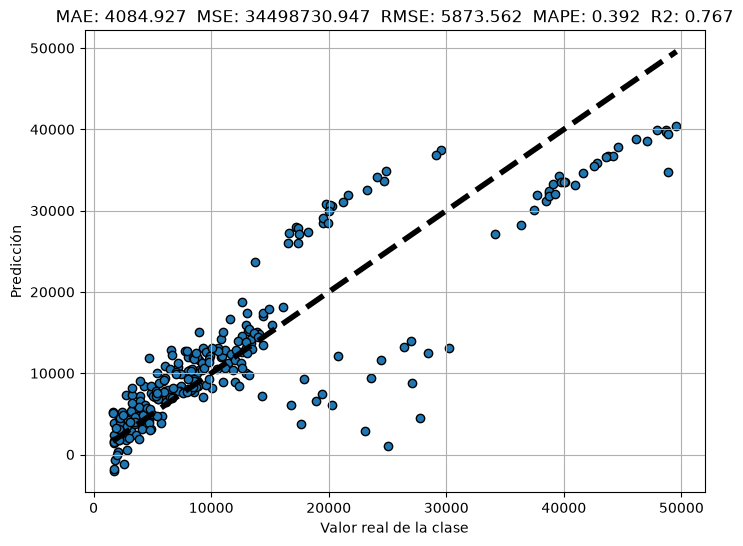

In [36]:
print("\n--- 9. Evaluación ---")
# Predicción del conjunto de test
y_pred_test = model.predict(X_test_std)

# Cálculo de las métricas de evaluación
MAE = metrics.mean_absolute_error(y_test, y_pred_test)
# Para MSE simplemente quitamos el parámetro squared
MSE = metrics.mean_squared_error(y_test, y_pred_test)
# Para RMSE aplicamos np.sqrt (raíz cuadrada de numpy) al MSE
RMSE = np.sqrt(MSE)
MAPE = metrics.mean_absolute_percentage_error(y_test, y_pred_test)
R2 = metrics.r2_score(y_test, y_pred_test)

print('MAE:   %.4f' % MAE)
print('MSE:   %.4f' % MSE)
print('RMSE:  %.4f' % RMSE)
print('MAPE:  %.4f' % MAPE)
print('R2:    %.4f' % R2)

comparacion = pd.DataFrame({'Valor Real': y_test.values, 'Predicción Modelo': y_pred_test})
comparacion['Diferencia'] = abs(comparacion['Valor Real'] - comparacion['Predicción Modelo'])
print("\nComparación de datos Reales vs Modelo (Primeros 10 pacientes):")
display(comparacion.head(10))

# Gráfica de realidad vs. predicción
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(y_test, y_pred_test, edgecolors=(0,0,0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f  MSE: %.3f  RMSE: %.3f  MAPE: %.3f  R2: %.3f" % (MAE, MSE, RMSE, MAPE, R2))
plt.grid()
plt.show()

# Predicción con nuevos datos

In [35]:
print("\n--- 10. Predicción con nuevos datos ---")
nuevo_paciente = np.array([[30, 25.5, 1, 1, 0, 1, 0, 0]])
nuevo_paciente_std = standardizer.transform(nuevo_paciente)
gasto_predicho = model.predict(nuevo_paciente_std)
print(f"El gasto médico estimado (charges) para el nuevo paciente es: ${gasto_predicho[0]:.2f}")


--- 10. Predicción con nuevos datos ---
El gasto médico estimado (charges) para el nuevo paciente es: $4514.11


C:\Users\mathe\anaconda3\envs\machinelearning2\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
